c:\Users\babie\OneDrive
c:\Users\babie
train loss:2.288898498405224
=== epoch:1, train acc:0.178, test acc:0.203 ===
train loss:2.2758019245239693
train loss:2.253292291539472
train loss:2.2256900666789443
train loss:2.1874067580892786
train loss:2.103494246441192
train loss:2.012618612340983
train loss:1.9823753543446032
train loss:1.900152819246264
train loss:1.7493552998623154
train loss:1.5777365307650555
train loss:1.4535737447688142
train loss:1.3161655073401928
train loss:1.072546879350903
train loss:1.066336035864849
train loss:1.0515068677343384
train loss:0.9117531221247752
train loss:0.8022302482722021
train loss:0.7939375495275441
train loss:0.7041294005569436
train loss:0.6782723137322368
train loss:0.7221222818571895
train loss:0.7245851511682297
train loss:0.5463635891397685
train loss:0.6662637076592499
train loss:0.5677219911369402
train loss:0.6210758351440286
train loss:0.5049825749563017
train loss:0.431317001007809
train loss:0.40592699602572924
train loss:0.478187

ValueError: x and y must have same first dimension, but have shapes (30,) and (2,)

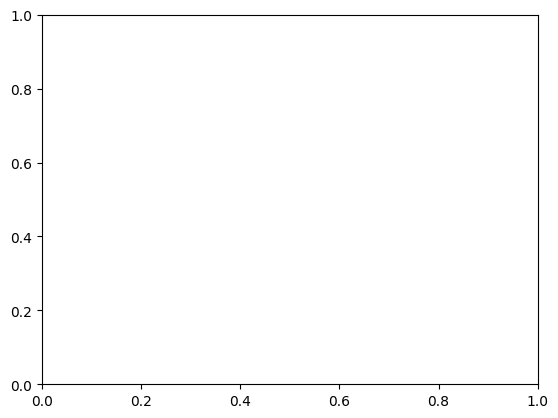

In [4]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from ch06.simple_convnet import SimpleConvNet
from common.trainer import Trainer

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

# 시간이 오래 걸릴 경우 데이터를 줄인다.
x_train, t_train = x_train[:5000], t_train[:5000]
x_test, t_test = x_test[:1000], t_test[:1000]

max_epochs = 30

network = SimpleConvNet(input_dim=(1, 28, 28),
                        conv_param={'filter_num': 64, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=256, output_size=10, weight_init_std=0.01)

trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=128,
                  optimizer='Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)

trainer.train()

# 매개변수 보존
network.save_params("params.pkl")
print("Saved Network Parameters!")

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()
